# RFM客户价值分层

本Notebook基于具有客户编号的正常销售记录计算RFM指标：

- Recency：距离客户最近一次购买的天数
- Frequency：客户的去重销售订单量
- Monetary：客户累计正常销售额

分析日期设为数据中最后交易日期的下一天。R、F、M分别使用1至5分评分，并根据评分组合划分客户群体。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}"
)

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = (
    project_root
    / "data"
    / "processed"
    / "transactions_clean.csv"
)

rfm_output_path = (
    project_root
    / "data"
    / "processed"
    / "customer_rfm.csv"
)

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(
    data_path,
    dtype={
        "InvoiceNo": "string",
        "CustomerID": "string",
        "TransactionType": "category",
    },
    parse_dates=["InvoiceDate"],
    usecols=[
        "InvoiceNo",
        "InvoiceDate",
        "CustomerID",
        "LineAmount",
        "TransactionType",
    ],
)

df["LineAmount"] = df["LineAmount"].round(3)

sales = df.loc[
    df["TransactionType"].eq("Sale")
    & df["CustomerID"].notna()
].copy()

analysis_date = (
    sales["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

print("分析日期：", analysis_date)
print("客户分析明细数：", len(sales))
print("可识别客户数：", sales["CustomerID"].nunique())

分析日期： 2011-12-10 00:00:00
客户分析明细数： 392692
可识别客户数： 4338


In [2]:
rfm = (
    sales
    .groupby("CustomerID")
    .agg(
        LastPurchaseDate=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineAmount", "sum"),
    )
    .reset_index()
)

rfm["AnalysisDate"] = analysis_date

rfm["Recency"] = (
    rfm["AnalysisDate"]
    - rfm["LastPurchaseDate"].dt.normalize()
).dt.days

rfm["Monetary"] = rfm["Monetary"].round(2)

rfm = rfm[
    [
        "CustomerID",
        "AnalysisDate",
        "LastPurchaseDate",
        "Recency",
        "Frequency",
        "Monetary",
    ]
]

display(rfm.head())

print("客户数：", len(rfm))
print(
    "Recency范围：",
    rfm["Recency"].min(),
    "至",
    rfm["Recency"].max()
)
print("客户订单量合计：", rfm["Frequency"].sum())
print("客户销售额合计：", round(rfm["Monetary"].sum(), 2))

,CustomerID,AnalysisDate,LastPurchaseDate,Recency,Frequency,Monetary
0,12346,2011-12-10,2011-01-18 10:01:00,326,1,"77,183.60"
1,12347,2011-12-10,2011-12-07 15:52:00,3,7,"4,310.00"
2,12348,2011-12-10,2011-09-25 13:13:00,76,4,"1,797.24"
3,12349,2011-12-10,2011-11-21 09:51:00,19,1,"1,757.55"
4,12350,2011-12-10,2011-02-02 16:01:00,311,1,334.40


客户数： 4338
Recency范围： 1 至 374
客户订单量合计： 18532
客户销售额合计： 8887208.89


In [3]:
def percentile_score(series, higher_is_better=True):
    """
    根据百分位排名划分1至5分。
    method='average'保证相同数值获得相同排名。
    """
    score = np.ceil(
        series.rank(method="average", pct=True) * 5
    )

    if not higher_is_better:
        score = 6 - score

    return score.astype("int64")


# Recency越小越好
rfm["R_Score"] = percentile_score(
    rfm["Recency"],
    higher_is_better=False,
)

# Frequency和Monetary越大越好
rfm["F_Score"] = percentile_score(
    rfm["Frequency"],
    higher_is_better=True,
)

rfm["M_Score"] = percentile_score(
    rfm["Monetary"],
    higher_is_better=True,
)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

display(
    rfm[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score",
        ]
    ].head()
)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,"77,183.60",1,1,5,115
1,12347,3,7,"4,310.00",5,5,5,555
2,12348,76,4,"1,797.24",2,4,4,244
3,12349,19,1,"1,757.55",4,1,4,414
4,12350,311,1,334.40,1,1,2,112


In [4]:
r = rfm["R_Score"]
f = rfm["F_Score"]
m = rfm["M_Score"]

segment_conditions = [
    (r >= 4) & (f >= 4) & (m >= 4),
    (r <= 2) & (f >= 3) & (m >= 3),
    (r >= 3) & (f >= 4),
    (r == 5) & (f == 1),
    (r >= 4) & f.between(2, 3),
    (r <= 2) & (f <= 2),
]

segment_names = [
    "Champions",
    "At Risk",
    "Loyal Customers",
    "New Customers",
    "Potential Loyalists",
    "Hibernating",
]

rfm["Segment"] = np.select(
    segment_conditions,
    segment_names,
    default="Need Attention",
)

segment_explanation = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "New Customers",
        "Need Attention",
        "At Risk",
        "Hibernating",
    ],
    "Meaning": [
        "近期购买频繁且贡献较高的核心客户",
        "近期仍有购买且订单频率较高的忠诚客户",
        "近期活跃并具有进一步培养潜力的客户",
        "最近首次购买的新客户",
        "表现中等，需要进一步观察或激活的客户",
        "过去贡献较高但近期不活跃的客户",
        "长期未购买且历史购买频率较低的客户",
    ],
})

display(segment_explanation)

,Segment,Meaning
0,Champions,近期购买频繁且贡献较高的核心客户
1,Loyal Customers,近期仍有购买且订单频率较高的忠诚客户
2,Potential Loyalists,近期活跃并具有进一步培养潜力的客户
3,New Customers,最近首次购买的新客户
4,Need Attention,表现中等，需要进一步观察或激活的客户
5,At Risk,过去贡献较高但近期不活跃的客户
6,Hibernating,长期未购买且历史购买频率较低的客户


In [5]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        CustomerCount=("CustomerID", "count"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        AverageMonetary=("Monetary", "mean"),
        SalesAmount=("Monetary", "sum"),
    )
)

segment_summary["CustomerPercent"] = (
    100
    * segment_summary["CustomerCount"]
    / len(rfm)
)

segment_summary["SalesPercent"] = (
    100
    * segment_summary["SalesAmount"]
    / rfm["Monetary"].sum()
)

segment_summary = segment_summary.sort_values(
    "SalesAmount",
    ascending=False,
)

expected_segment_counts = {
    "Champions": 911,
    "Need Attention": 999,
    "Hibernating": 962,
    "At Risk": 534,
    "Potential Loyalists": 484,
    "Loyal Customers": 381,
    "New Customers": 67,
}

actual_segment_counts = (
    rfm["Segment"].value_counts().to_dict()
)

assert len(rfm) == 4338
assert rfm["CustomerID"].is_unique
assert rfm["Recency"].between(1, 374).all()
assert rfm["R_Score"].between(1, 5).all()
assert rfm["F_Score"].between(1, 5).all()
assert rfm["M_Score"].between(1, 5).all()
assert rfm["Segment"].notna().all()
assert actual_segment_counts == expected_segment_counts
assert np.isclose(
    rfm["Monetary"].sum(),
    8887208.89,
    atol=0.01,
)

display(segment_summary.round(2))

print("RFM分群验证通过")

,CustomerCount,AverageRecency,AverageFrequency,AverageMonetary,SalesAmount,CustomerPercent,SalesPercent
Segment,,,,,,,
Champions,911,12.85,11.50,"6,230.67","5,676,143.38",21.00,63.87
At Risk,534,144.44,3.56,"1,586.87","847,389.02",12.31,9.53
Loyal Customers,381,39.50,5.80,"2,161.41","823,495.76",8.78,9.27
Potential Loyalists,484,16.93,2.42,"1,204.79","583,120.23",11.16,6.56
Need Attention,999,76.79,1.75,514.74,"514,222.58",23.03,5.79
Hibernating,962,222.85,1.00,436.31,"419,725.82",22.18,4.72
New Customers,67,7.72,1.00,344.96,"23,112.10",1.54,0.26


RFM分群验证通过


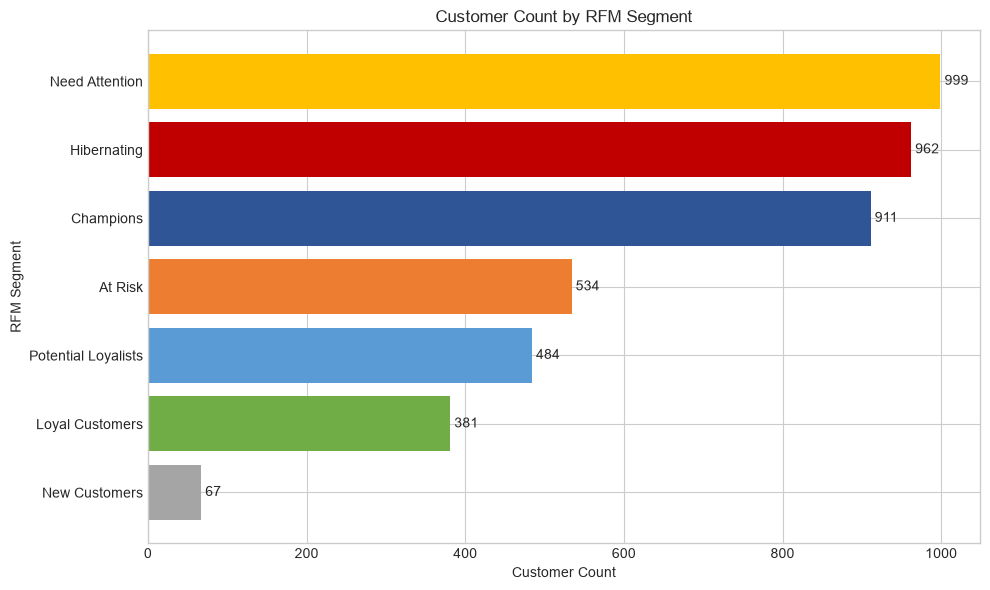

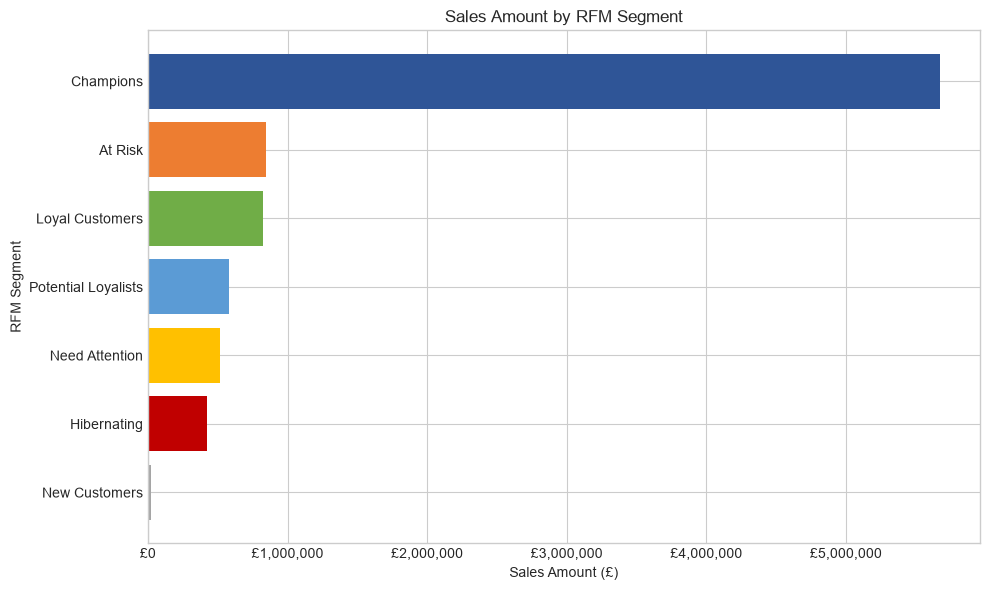

In [6]:
segment_colors = {
    "Champions": "#2F5597",
    "Loyal Customers": "#70AD47",
    "Potential Loyalists": "#5B9BD5",
    "New Customers": "#A5A5A5",
    "Need Attention": "#FFC000",
    "At Risk": "#ED7D31",
    "Hibernating": "#C00000",
}


# 图1：各客户群体客户数
customer_plot = segment_summary.sort_values(
    "CustomerCount"
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    customer_plot.index,
    customer_plot["CustomerCount"],
    color=[
        segment_colors[name]
        for name in customer_plot.index
    ],
)

ax.set_title("Customer Count by RFM Segment")
ax.set_xlabel("Customer Count")
ax.set_ylabel("RFM Segment")
ax.bar_label(bars, padding=3)

fig.tight_layout()
fig.savefig(
    figures_dir / "rfm_segment_customers.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


# 图2：各客户群体销售额
sales_plot = segment_summary.sort_values(
    "SalesAmount"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    sales_plot.index,
    sales_plot["SalesAmount"],
    color=[
        segment_colors[name]
        for name in sales_plot.index
    ],
)

ax.set_title("Sales Amount by RFM Segment")
ax.set_xlabel("Sales Amount (£)")
ax.set_ylabel("RFM Segment")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("£{x:,.0f}")
)

fig.tight_layout()
fig.savefig(
    figures_dir / "rfm_segment_sales.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [7]:
rfm_output = rfm[
    [
        "CustomerID",
        "AnalysisDate",
        "LastPurchaseDate",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Total",
        "RFM_Score",
        "Segment",
    ]
].sort_values(
    ["Segment", "Monetary"],
    ascending=[True, False],
)

rfm_output.to_csv(
    rfm_output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d %H:%M:%S",
    float_format="%.2f",
)

expected_figures = [
    figures_dir / "rfm_segment_customers.png",
    figures_dir / "rfm_segment_sales.png",
]

assert rfm_output_path.exists()
assert all(path.exists() for path in expected_figures)

rfm_reloaded = pd.read_csv(
    rfm_output_path,
    dtype={
        "CustomerID": "string",
        "RFM_Score": "string",
        "Segment": "string",
    },
)

assert rfm_reloaded.shape == (4338, 12)
assert rfm_reloaded["CustomerID"].is_unique
assert rfm_reloaded["Segment"].notna().all()

print("全部RFM分析验证通过")
print("RFM文件：", rfm_output_path)
print("RFM文件形状：", rfm_reloaded.shape)

for path in expected_figures:
    print(path.name, path.stat().st_size, "bytes")

全部RFM分析验证通过
RFM文件： c:\Users\a\Documents\DataAnalysisProjects\ecommerce-customer-analysis\data\processed\customer_rfm.csv
RFM文件形状： (4338, 12)
rfm_segment_customers.png 49068 bytes
rfm_segment_sales.png 48079 bytes
